# Task 3: NanoGPT

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os
from collections import Counter

print('PyTorch version:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

PyTorch version: 2.2.2
Using device: cpu


## 3.1: Data Preparation

We use the standard tiny-Shakespeare dataset 

In [ ]:
# Download Shakespeare text
data_path = 'shakespeare.txt'
if not os.path.exists(data_path):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, data_path)
    print('Downloaded shakespeare.txt')
else:
    print('shakespeare.txt already exists')

with open(data_path, 'r', encoding='utf-8') as f:
    text = f.read()

print(f'Total characters: {len(text):,}')
print(f'\nFirst 300 characters:')
print(text[:300])

shakespeare.txt already exists
Total characters: 1,115,394

First 300 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [3]:
# Character-level tokenisation: each unique character becomes an integer
chars = sorted(set(text))
vocab_size = len(chars)
print(f'Vocabulary size: {vocab_size} unique characters')
print(f'Characters: {repr("".join(chars))}')

# Create mappings between characters and integers
stoi = {ch: i for i, ch in enumerate(chars)}  # char -> int
itos = {i: ch for i, ch in enumerate(chars)}  # int -> char

encode = lambda s: [stoi[c] for c in s]        # string -> list of ints
decode = lambda l: ''.join([itos[i] for i in l])  # list of ints -> string

# Check encoding/decoding works
test_str = 'Hello World'
print(f'\nTest encode/decode: "{test_str}" -> {encode(test_str)} -> "{decode(encode(test_str))}"')

Vocabulary size: 65 unique characters
Characters: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

Test encode/decode: "Hello World" -> [20, 43, 50, 50, 53, 1, 35, 53, 56, 50, 42] -> "Hello World"


In [21]:
# Encode entire text as a tensor of integers
data = torch.tensor(encode(text), dtype=torch.long)
print(f'Data shape: {data.shape}')

# Split into train (90%) and validation (10%) sets
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f'Train tokens: {len(train_data):,}')
print(f'Val tokens:   {len(val_data):,}')

Data shape: torch.Size([1115394])
Train tokens: 1,003,854
Val tokens:   111,540


In [5]:
# Hyperparameters (set to small values so it trains in reasonable time on CPU)
batch_size = 32     # how many sequences per training batch
block_size = 64     # context window length (each input is block_size characters)
n_embd = 64         # embedding dimension
n_head = 4          # number of attention heads (will vary this for the experiment)
n_layer = 4         # number of transformer blocks
dropout = 0.1       # dropout rate
learning_rate = 1e-3
max_iters = 5000    # total training steps
eval_interval = 500 # how often to evaluate on validation set

torch.manual_seed(42)

def get_batch(split):
    """Sample a random batch of sequences."""
    source = train_data if split == 'train' else val_data
    # random start positions
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i+block_size] for i in ix])
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

# Show one batch to check it works
xb, yb = get_batch('train')
print(f'Input batch shape: {xb.shape}')   # (batch_size, block_size)
print(f'Target batch shape: {yb.shape}')
print(f'\nFirst input sequence:  {decode(xb[0].tolist())[:50]!r}')
print(f'First target sequence: {decode(yb[0].tolist())[:50]!r}')

Input batch shape: torch.Size([32, 64])
Target batch shape: torch.Size([32, 64])

First input sequence:  'Paris!\nWhat said my man, when my betossed soul\nDid'
First target sequence: 'aris!\nWhat said my man, when my betossed soul\nDid '


## 3.2: Model Architecture

A decoder-only transformer. Each character is embedded into a 64-dim vector, positional embeddings are added, then the sequence passes through 4 transformer blocks before a linear head produces logits over the 65-character vocabulary.

In [6]:
class Head(nn.Module):
    """One self-attention head."""

    def __init__(self, head_size):
        super().__init__()
        # linear projections to compute Q, K, V from the input embeddings
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # lower-triangular mask for causal (autoregressive) attention
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape  # batch, sequence length, embedding dim

        k = self.key(x)    # (B, T, head_size)
        q = self.query(x)  # (B, T, head_size)
        v = self.value(x)  # (B, T, head_size)

        # scaled dot-product attention: Q K^T / sqrt(d_k)
        scale = k.shape[-1] ** -0.5
        wei = q @ k.transpose(-2, -1) * scale  # (B, T, T)

        # mask out future positions (causal: can only look at past tokens)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)  # (B, T, T)
        wei = self.dropout(wei)

        # weighted sum of values
        out = wei @ v  # (B, T, head_size)
        return out

### Multi-Head Attention

`n_head` heads run in parallel, each with `head_size = n_embd // n_head`. Outputs are concatenated and projected back to `n_embd`.

In [7]:
class MultiHeadAttention(nn.Module):
    """Multiple attention heads running in parallel, concatenated."""

    def __init__(self, num_heads, head_size):
        super().__init__()
        # each head is an independent attention module
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        # project concatenated outputs back to n_embd
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # run all heads in parallel and concatenate along the last dimension
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # (B, T, n_embd)
        out = self.dropout(self.proj(out))
        return out

### Feed-Forward + Transformer Block

In [8]:
class FeedForward(nn.Module):
    """Simple two-layer MLP applied to each position independently."""

    def __init__(self, n_embd):
        super().__init__()
        # expand to 4x n_embd in the hidden layer (standard GPT choice)
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """One transformer block: attention -> feed-forward, both with residual connections."""

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)  # self-attention
        self.ffwd = FeedForward(n_embd)
        self.ln1  = nn.LayerNorm(n_embd)  # pre-norm (applied before each sub-layer)
        self.ln2  = nn.LayerNorm(n_embd)

    def forward(self, x):
        # residual connection: output = input + sub-layer(norm(input))
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

### Full GPT Model

In [9]:
class GPTLanguageModel(nn.Module):

    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size
        # token embedding table: maps each character index to a learned vector
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # positional embedding: learned vector for each position in the context
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        # stack of transformer blocks
        self.blocks = nn.Sequential(
            *[Block(n_embd, n_head) for _ in range(n_layer)]
        )
        # final layer norm before the output head
        self.ln_f = nn.LayerNorm(n_embd)
        # linear head: maps n_embd -> vocab_size (produces logits)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # token + positional embeddings added together
        tok_emb = self.token_embedding_table(idx)               # (B, T, n_embd)
        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device)                       # (T, n_embd)
        )
        x = tok_emb + pos_emb                                    # (B, T, n_embd)

        # pass through transformer blocks
        x = self.blocks(x)                                       # (B, T, n_embd)
        x = self.ln_f(x)                                         # (B, T, n_embd)

        # project to vocabulary logits
        logits = self.lm_head(x)                                 # (B, T, vocab_size)

        # compute cross-entropy loss if targets are provided
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            # reshape for cross-entropy: (B*T, vocab_size) vs (B*T,)
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        """Autoregressively generate new tokens."""
        for _ in range(max_new_tokens):
            # crop context to the last block_size tokens
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            # take logits at the last position only
            logits = logits[:, -1, :] / temperature   # (B, vocab_size)
            probs = F.softmax(logits, dim=-1)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            idx = torch.cat((idx, idx_next), dim=1)             # (B, T+1)
        return idx

## 3.3: Training Loop

In [10]:
@torch.no_grad()
def estimate_loss(model, eval_iters=100):
    """Average the loss over a few batches for a more stable estimate."""
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [11]:
def train_model(n_head, label='model', max_iters=max_iters):
    """Train a GPT model with a given number of attention heads."""
    torch.manual_seed(42)

    model = GPTLanguageModel(
        vocab_size=vocab_size,
        n_embd=n_embd,
        n_head=n_head,
        n_layer=n_layer,
        block_size=block_size,
        dropout=dropout
    ).to(device)

    num_params = sum(p.numel() for p in model.parameters())
    print(f'[{label}] Parameters: {num_params:,}  |  n_head={n_head}')

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    iters_recorded = []

    for iteration in range(max_iters):
        # periodically evaluate on both splits
        if iteration % eval_interval == 0 or iteration == max_iters - 1:
            losses = estimate_loss(model)
            print(f'  step {iteration:4d}: train loss {losses["train"]:.4f}, val loss {losses["val"]:.4f}')
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            iters_recorded.append(iteration)

        # forward pass + backprop
        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return model, train_losses, val_losses, iters_recorded

## 3.4: Hyperparameter Study

We train two versions of the model:
- **Config A** (`n_head=2`): each head has size `n_embd/2 = 32`, fewer but larger heads
- **Config B** (`n_head=4`): each head has size `n_embd/4 = 16`, more but smaller heads

All other hyperparameters are kept identical. More heads can in theory capture more diverse attention patterns, but each head has less capacity.

In [12]:
print('Training Config A: n_head=2')
print('=' * 50)
model_a, train_losses_a, val_losses_a, iters_a = train_model(n_head=2, label='n_head=2')

Training Config A: n_head=2
[n_head=2] Parameters: 211,777  |  n_head=2
  step    0: train loss 4.3115, val loss 4.3169
  step  500: train loss 2.2095, val loss 2.2266
  step 1000: train loss 1.9822, val loss 2.0385
  step 1500: train loss 1.8534, val loss 1.9495
  step 2000: train loss 1.7723, val loss 1.8886
  step 2500: train loss 1.7114, val loss 1.8551
  step 3000: train loss 1.6816, val loss 1.8282
  step 3500: train loss 1.6425, val loss 1.8103
  step 4000: train loss 1.6257, val loss 1.7970
  step 4500: train loss 1.6031, val loss 1.7843
  step 4999: train loss 1.5839, val loss 1.7707


In [13]:
print('Training Config B: n_head=4')
print('=' * 50)
model_b, train_losses_b, val_losses_b, iters_b = train_model(n_head=4, label='n_head=4')

Training Config B: n_head=4
[n_head=4] Parameters: 211,777  |  n_head=4
  step    0: train loss 4.2836, val loss 4.2889
  step  500: train loss 2.2680, val loss 2.2848
  step 1000: train loss 2.0152, val loss 2.0734
  step 1500: train loss 1.8668, val loss 1.9654
  step 2000: train loss 1.7799, val loss 1.9114
  step 2500: train loss 1.7188, val loss 1.8600
  step 3000: train loss 1.6697, val loss 1.8250
  step 3500: train loss 1.6390, val loss 1.8091
  step 4000: train loss 1.6059, val loss 1.7888
  step 4500: train loss 1.5963, val loss 1.7609
  step 4999: train loss 1.5806, val loss 1.7435


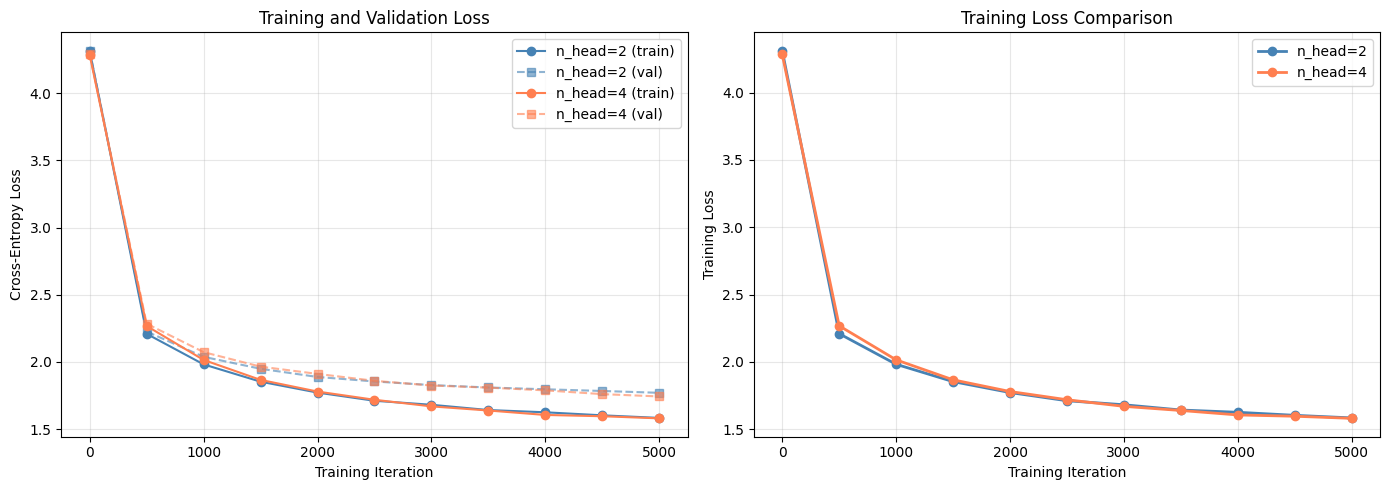


Final results:
  n_head=2: train loss = 1.5839, val loss = 1.7707
  n_head=4: train loss = 1.5806, val loss = 1.7435


In [27]:
# Compare training loss curves for the two configurations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(iters_a, train_losses_a, 'o-', label='n_head=2 (train)', color='steelblue')
axes[0].plot(iters_a, val_losses_a,   's--', label='n_head=2 (val)',   color='steelblue', alpha=0.6)
axes[0].plot(iters_b, train_losses_b, 'o-', label='n_head=4 (train)', color='coral')
axes[0].plot(iters_b, val_losses_b,   's--', label='n_head=4 (val)',   color='coral', alpha=0.6)
axes[0].set_xlabel('Training Iteration')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Training loss only (cleaner view)
axes[1].plot(iters_a, train_losses_a, 'o-', label='n_head=2', color='steelblue', linewidth=2)
axes[1].plot(iters_b, train_losses_b, 'o-', label='n_head=4', color='coral', linewidth=2)
axes[1].set_xlabel('Training Iteration')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('Training Loss Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nanogpt_loss_curves.png', dpi=100)
plt.show()

print(f'\nFinal results:')
print(f'  n_head=2: train loss = {train_losses_a[-1]:.4f}, val loss = {val_losses_a[-1]:.4f}')
print(f'  n_head=4: train loss = {train_losses_b[-1]:.4f}, val loss = {val_losses_b[-1]:.4f}')

## 3.5: Text Generation and Analysis

We generate sample text from the best-performing model starting from a newline character as the initial context.

In [39]:
if val_losses_a[-1] <= val_losses_b[-1]:
    best_model = model_a
    best_config = 'n_head=2'
else:
    best_model = model_b
    best_config = 'n_head=4'

print(f'Best model: {best_config}')

torch.manual_seed(42)
best_model.eval()
start_token = torch.zeros((1, 1), dtype=torch.long, device=device)
generated = best_model.generate(start_token, max_new_tokens=500, temperature=1.0)
generated_text = decode(generated[0].tolist())
print('\n--- Generated Text (500 characters) ---')
print(generated_text)

Best model: n_head=4

--- Generated Text (500 characters) ---

Margant unto may them staintler Rome assuand what will chee,
A now the and had woupe to so to trave tears of a spordlmy
Come, Plity-feforty'd subster afn all great since lark.

ROMEO:
I know no love's by him her you, since!

MURIANTIO:
Dost be day:
And against tell up.

RUCES:
Conto-mat inward woeth than this quit and there, again.

Perd:
But meas you may Here that theree? do not.

WARWICK:
Or and Grace me gate o' with to be read and thy hade
post it ruch rish with times lies you.

WARWICK:
Why 


In [32]:
torch.manual_seed(42)
for temp in [0.7, 1.0, 1.3]:
    start_token = torch.zeros((1, 1), dtype=torch.long, device=device)
    gen = best_model.generate(start_token, max_new_tokens=200, temperature=temp)
    gen_text = decode(gen[0].tolist())
    print(f'\n--- Temperature = {temp} ---')
    print(gen_text[:200])


--- Temperature = 0.7 ---

Marry me by shall seek this life of thee the was
To a man some of my hear and in the ears it,
And we sair of a spoke myself may the sefe word subst a king,
And even in the leave of the live and of th

--- Temperature = 1.0 ---

Sech pass of the since! when ensiere, sprince are inward is toeth,
They had eneyal dist inward woeth than this quit and the
is again in exegrengments and mean not that theree? do not.

WARWICK:
Or an

--- Temperature = 1.3 ---

RGAHN:
O, gatius' with to
Frarrencamher you counsel'n, ruch, merring go
The ladiey me less did do resticile
Might; good saivenelts?
O, cy soze sudges; herppy, thou hasbindish;
Un'gding issentment to 


In [37]:
torch.manual_seed(42)
start_token = torch.zeros((1, 1), dtype=torch.long, device=device)
gen = best_model.generate(start_token, max_new_tokens=1000, temperature=1.0)
gen_text = decode(gen[0].tolist())

print('=== Generated Text Analysis ===')
print(f'Length: {len(gen_text)} characters')

lines = [l.strip() for l in gen_text.split('\n') if l.strip()]
cap_lines = [l for l in lines if l and l[0].isupper()]
print(f'Lines starting with capital letter: {len(cap_lines)}/{len(lines)} ({len(cap_lines)/max(1,len(lines))*100:.0f}%)')

punct_chars = [c for c in gen_text if c in '.,;:!?\'\"']
print(f'Punctuation count: {len(punct_chars)} ({len(punct_chars)/len(gen_text)*100:.1f}% of text)')

words = gen_text.lower().replace('\n', ' ').split()
print(f'\nTotal word tokens: {len(words)}')
word_freq = Counter(words)
print(f'Most common words: {word_freq.most_common(10)}')

shakespeare_words = ['thee', 'thou', 'thy', 'hath', 'doth', 'art', 'dost', 'hast']
found = [w for w in shakespeare_words if w in word_freq]
print(f'\nArchaic Shakespeare words found: {found}')

=== Generated Text Analysis ===
Length: 1001 characters
Lines starting with capital letter: 26/29 (90%)
Punctuation count: 41 (4.1% of text)

Total word tokens: 183
Most common words: [('and', 9), ('a', 4), ('the', 4), ('to', 4), ('with', 3), ('is', 3), ('he', 3), ('may', 2), ('will', 2), ('of', 2)]

Archaic Shakespeare words found: ['thy', 'dost']


In [38]:
# Final summary
print('Summary: Effect of Number of Attention Heads')
print('-' * 50)
print(f'n_head=2 | Final train loss: {train_losses_a[-1]:.4f} | Final val loss: {val_losses_a[-1]:.4f}')
print(f'n_head=4 | Final train loss: {train_losses_b[-1]:.4f} | Final val loss: {val_losses_b[-1]:.4f}')

Summary: Effect of Number of Attention Heads
--------------------------------------------------
n_head=2 | Final train loss: 1.5839 | Final val loss: 1.7707
n_head=4 | Final train loss: 1.5806 | Final val loss: 1.7435
